In [1]:
# ================================================
# SUPERSTORE SALES ANALYSIS USING PYTHON
# ================================================
# Tool: Python (Pandas + Matplotlib)
# Dataset: Superstore (9800 rows)
# Analyst: Mohan R
# ================================================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("SuperStoreCSV.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Year"] = df["Order Date"].dt.year
df["Month Name"] = df["Order Date"].dt.strftime("%B")

print("Setup Complete!")
print("Dataset Shape:", df.shape)
print("Years Available:", df["Year"].unique())

Setup Complete!
Dataset Shape: (9800, 20)
Years Available: [2017 2016 2015 2018]


In [2]:
# ================================================
# DATA OVERVIEW
# ================================================

print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Summary:")
print(df.describe())

Total Rows: 9800
Total Columns: 20

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month Name        0
dtype: int64

Data Summary:
            Row ID                     Order Date   Postal Code         Sales  \
count  9800.000000                           9800   9789.000000   9800.000000   
mean   4900.500000  2017-05-01 05:13:51.673469440  55273.322403    230.769059   
min       1.000000            2015-01-03 00:00:00   1040.000000      0.444000   
25%    2450.750000            2016-05-24 00:00:00  23223.000000     17.248000   
50%    4900.500000            2017-06-26 00:00:00  58103.000000     54.490000   
75%    7350.250000            2018

SALES BY REGION:
    Region  total_sales  total_orders  avg_sale
0     West    710219.68          3140    226.18
1     East    669518.73          2785    240.40
2  Central    492646.91          2277    216.36
3    South    389151.46          1598    243.52

Best Region: West
Best Region Sales: $ 710219.68


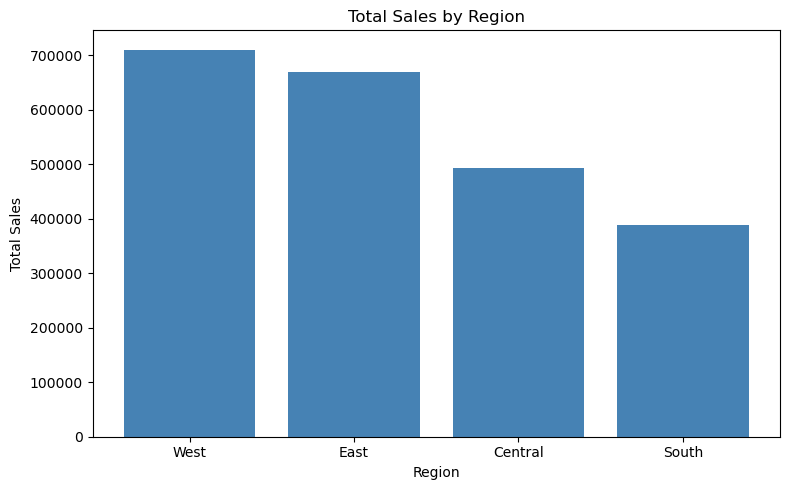

In [3]:
# ================================================
# ANALYSIS 1: SALES BY REGION
# ================================================

region_sales = df.groupby("Region")["Sales"].agg(
    total_sales="sum",
    total_orders="count",
    avg_sale="mean"
).reset_index()

region_sales["total_sales"] = region_sales["total_sales"].round(2)
region_sales["avg_sale"] = region_sales["avg_sale"].round(2)
region_sales = region_sales.sort_values("total_sales", ascending=False)
region_sales = region_sales.reset_index(drop=True)

print("SALES BY REGION:")
print(region_sales)
print("\nBest Region:", region_sales["Region"][0])
print("Best Region Sales: $", region_sales["total_sales"][0])

plt.figure(figsize=(8, 5))
plt.bar(region_sales["Region"], region_sales["total_sales"], color="steelblue")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

SALES BY CATEGORY:
          Category  total_sales  total_orders  avg_sale
0       Technology    827455.87          1813    456.40
1        Furniture    728658.58          2078    350.65
2  Office Supplies    705422.33          5909    119.38

Best Category: Technology
Best Category Sales: $ 827455.87


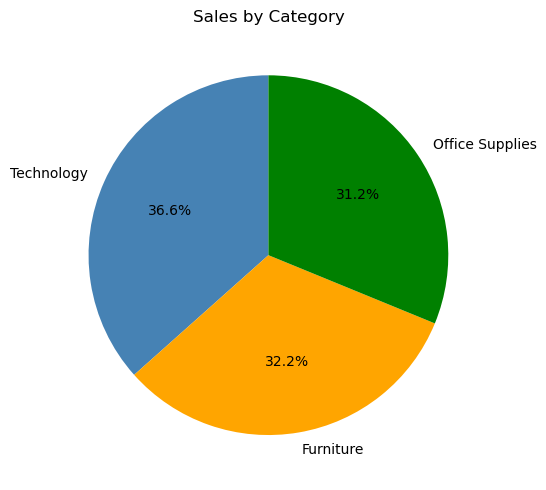

In [4]:
# ================================================
# ANALYSIS 2: SALES BY CATEGORY
# ================================================

category_sales = df.groupby("Category")["Sales"].agg(
    total_sales="sum",
    total_orders="count",
    avg_sale="mean"
).reset_index()

category_sales["total_sales"] = category_sales["total_sales"].round(2)
category_sales["avg_sale"] = category_sales["avg_sale"].round(2)
category_sales = category_sales.sort_values("total_sales", ascending=False)
category_sales = category_sales.reset_index(drop=True)

print("SALES BY CATEGORY:")
print(category_sales)
print("\nBest Category:", category_sales["Category"][0])
print("Best Category Sales: $", category_sales["total_sales"][0])

plt.figure(figsize=(8, 5))
plt.pie(
    category_sales["total_sales"],
    labels=category_sales["Category"],
    autopct="%1.1f%%",
    colors=["steelblue", "orange", "green"],
    startangle=90
)
plt.title("Sales by Category")
plt.tight_layout()
plt.show()

SALES BY SEGMENT:
       Segment  total_sales  total_orders  avg_sale
0     Consumer   1148060.53          5101    225.07
1    Corporate    688494.07          2953    233.15
2  Home Office    424982.18          1746    243.40

Best Segment: Consumer
Best Segment Sales: $ 1148060.53


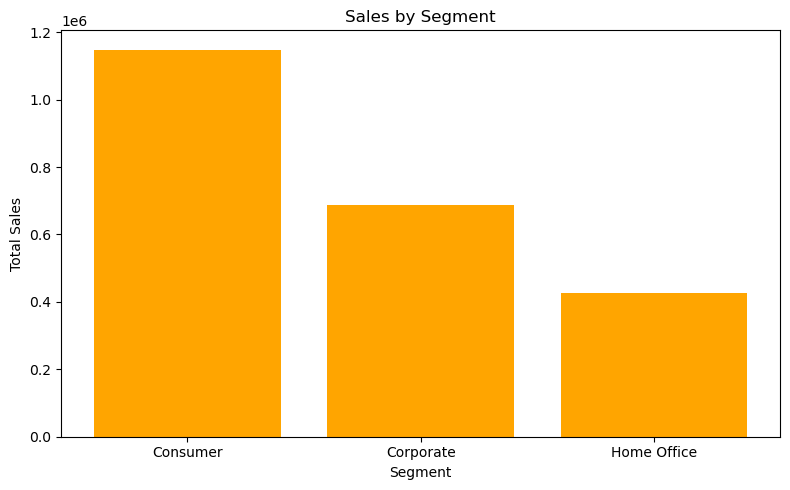

In [5]:
# ================================================
# ANALYSIS 3: SALES BY SEGMENT
# ================================================

segment_sales = df.groupby("Segment")["Sales"].agg(
    total_sales="sum",
    total_orders="count",
    avg_sale="mean"
).reset_index()

segment_sales["total_sales"] = segment_sales["total_sales"].round(2)
segment_sales["avg_sale"] = segment_sales["avg_sale"].round(2)
segment_sales = segment_sales.sort_values("total_sales", ascending=False)
segment_sales = segment_sales.reset_index(drop=True)

print("SALES BY SEGMENT:")
print(segment_sales)
print("\nBest Segment:", segment_sales["Segment"][0])
print("Best Segment Sales: $", segment_sales["total_sales"][0])

plt.figure(figsize=(8, 5))
plt.bar(segment_sales["Segment"], segment_sales["total_sales"], color="orange")
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

SALES BY MONTH:
   Month Name      Sales
4     January   94291.63
3    February   59371.12
7       March  197573.59
0       April  136283.00
8         May  154086.72
6        June  145837.52
5        July  145535.69
1      August  157315.93
11  September  300103.41
10    October  199496.29
9    November  350161.71
2    December  321480.17

Best Month: November
Worst Month: February


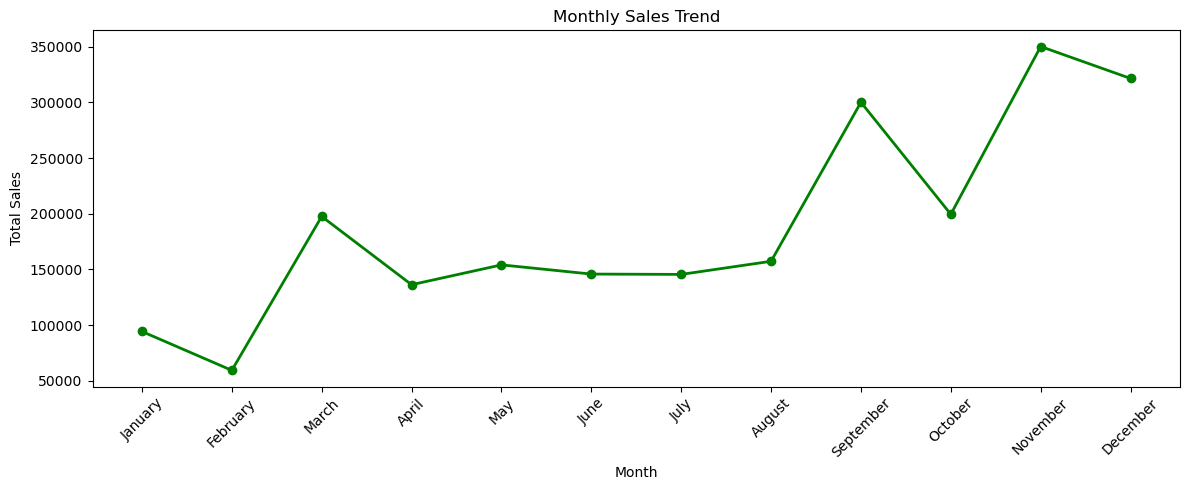

In [7]:
# ================================================
# ANALYSIS 4: MONTHLY SALES TREND
# ================================================

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

month_sales = df.groupby("Month Name")["Sales"].sum().reset_index()
month_sales["Month Name"] = pd.Categorical(
    month_sales["Month Name"],
    categories=month_order,
    ordered=True
)
month_sales = month_sales.sort_values("Month Name")
month_sales["Sales"] = month_sales["Sales"].round(2)

print("SALES BY MONTH:")
print(month_sales)
print("\nBest Month:", month_sales.loc[month_sales["Sales"].idxmax(), "Month Name"])
print("Worst Month:", month_sales.loc[month_sales["Sales"].idxmin(), "Month Name"])

plt.figure(figsize=(12, 5))
plt.plot(month_sales["Month Name"], month_sales["Sales"],
         color="green", marker="o", linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TOP 10 CUSTOMERS:
        Customer Name  Total Sales
0         Sean Miller     25043.05
1        Tamara Chand     19052.22
2        Raymond Buch     15117.34
3        Tom Ashbrook     14595.62
4       Adrian Barton     14473.57
5        Ken Lonsdale     14175.23
6        Sanjit Chand     14142.33
7        Hunter Lopez     12873.30
8        Sanjit Engle     12209.44
9  Christopher Conant     12129.07

Top Customer: Sean Miller
Top Customer Sales: $ 25043.05


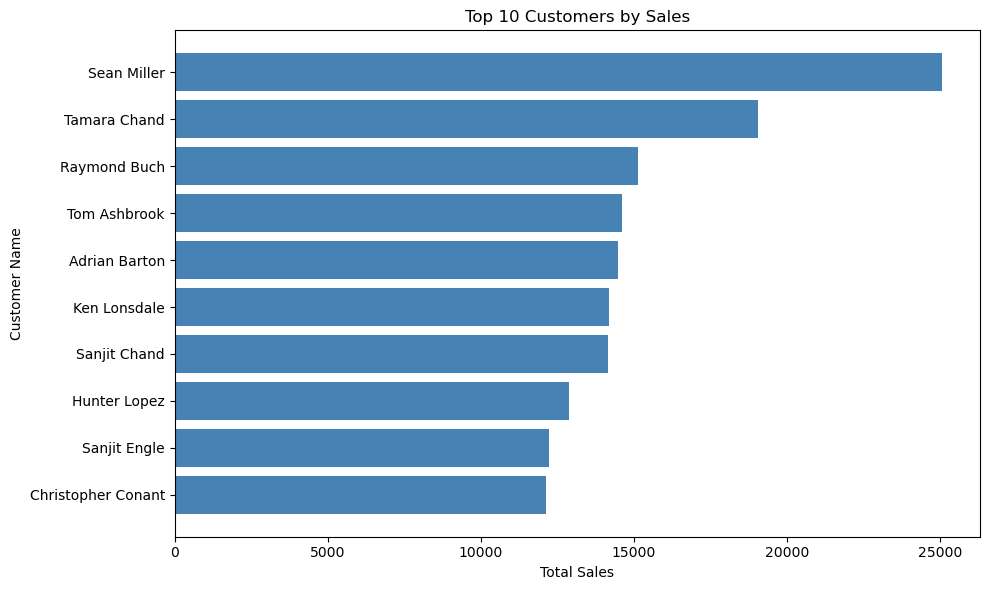

In [8]:
# ================================================
# ANALYSIS 5: TOP 10 CUSTOMERS
# ================================================

top_customers = df.groupby("Customer Name")["Sales"].sum().reset_index()
top_customers.columns = ["Customer Name", "Total Sales"]
top_customers["Total Sales"] = top_customers["Total Sales"].round(2)
top_customers = top_customers.sort_values("Total Sales", ascending=False).head(10)
top_customers = top_customers.reset_index(drop=True)

print("TOP 10 CUSTOMERS:")
print(top_customers)
print("\nTop Customer:", top_customers["Customer Name"][0])
print("Top Customer Sales: $", top_customers["Total Sales"][0])

plt.figure(figsize=(10, 6))
plt.barh(top_customers["Customer Name"], top_customers["Total Sales"], color="steelblue")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

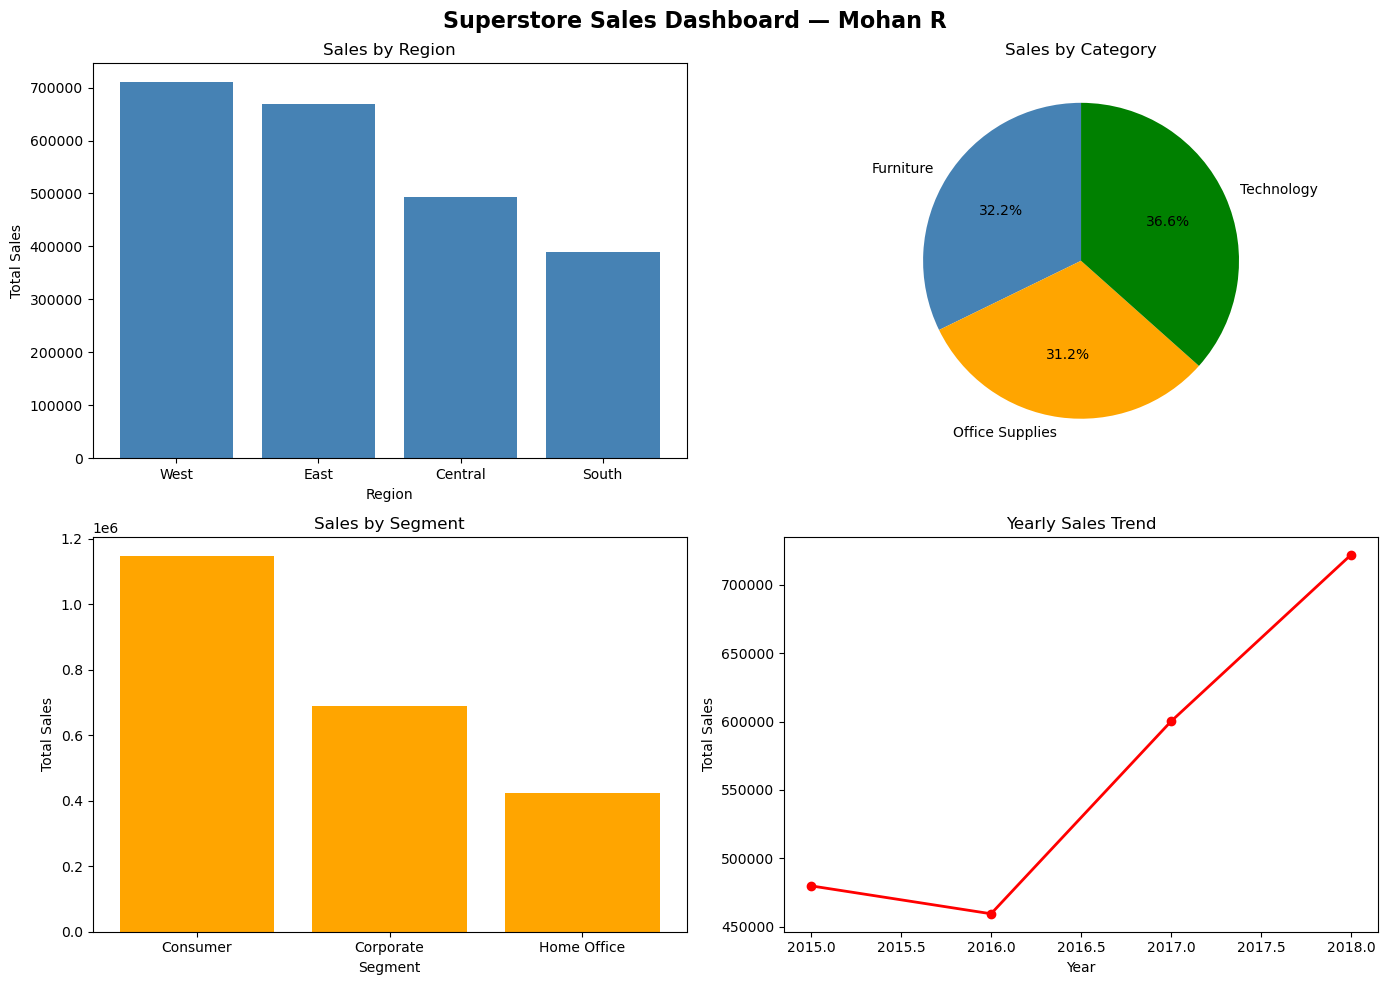

In [9]:
# ================================================
# FINAL DASHBOARD
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Superstore Sales Dashboard — Mohan R",
             fontsize=16, fontweight="bold")

# Chart 1 - Sales by Region
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
region_sales = region_sales.sort_values("Sales", ascending=False)
axes[0, 0].bar(region_sales["Region"], region_sales["Sales"], color="steelblue")
axes[0, 0].set_title("Sales by Region")
axes[0, 0].set_xlabel("Region")
axes[0, 0].set_ylabel("Total Sales")

# Chart 2 - Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().reset_index()
axes[0, 1].pie(
    category_sales["Sales"],
    labels=category_sales["Category"],
    autopct="%1.1f%%",
    colors=["steelblue", "orange", "green"],
    startangle=90
)
axes[0, 1].set_title("Sales by Category")

# Chart 3 - Sales by Segment
segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()
segment_sales = segment_sales.sort_values("Sales", ascending=False)
axes[1, 0].bar(segment_sales["Segment"], segment_sales["Sales"], color="orange")
axes[1, 0].set_title("Sales by Segment")
axes[1, 0].set_xlabel("Segment")
axes[1, 0].set_ylabel("Total Sales")

# Chart 4 - Yearly Trend
year_sales = df.groupby("Year")["Sales"].sum().reset_index()
axes[1, 1].plot(year_sales["Year"], year_sales["Sales"],
                color="red", marker="o", linewidth=2)
axes[1, 1].set_title("Yearly Sales Trend")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()